## Impl directories to analyze

In [12]:
from pathlib import Path

MODES = ["noDesign", "allAtOnce"] # , "allAtOnce", "byLayer"]
PROBLEM = "mocked_http"

dirs = [
    Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}") for x in MODES
]
dirs

[PosixPath('datasets/slopCodeBench/scb-problems/mocked_http/implementations_noDesign'),
 PosixPath('datasets/slopCodeBench/scb-problems/mocked_http/implementations_allAtOnce')]

## Functions with high CC
## Classes with high fan out

In [13]:
import os 
from metrics.designite_py.overall_metrics import get_dpy_metrics

# An array of arrays, each of length N 
# where N is the number of checkpoints of the problem 
data = [] 

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint 
    mode_metrics = []  # metrics of all checkpoints, for a single mode 
    for i, checkpoint_name in enumerate(checkpoint_dirs): 
        impl_dir = dirs[mode_no] / checkpoint_name
        
        mode_metrics.append(
            get_dpy_metrics(implementation_path=impl_dir)
        )
    
    data.append(mode_metrics) 

print(data)

[1/2] DPy metrics
invoking license validation...
DPy version 1.7.8 Trial
Copyright (c) Designite 2026.
Current Configuration:
  Input Path: /home/bernardmoy/modular-SWE/datasets/slopCodeBench/scb-problems/mocked_http/implementations_noDesign/checkpoint_1
  Output Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
  Output Format: json
  Configuration File: /tmp/onefile_169599_1783725016_433433/default_config.json
  Log Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
invoking license validation...
License type: LicenseType.Trial
Parsing ...
Calculating metrics ...
Detecting code smells ...
Detecting design smells ...
Detecting architecture smells ...
Detecting machine learning smells ...
Collect dependencies ...
Analysis complete.
Preparing analysis summary ...
--Analysis summary--
	Total LOC analyzed: 645	Number of packages: 1
	Number of classes: 8	Number of modules: 5
	number of methods/functions: 57
-Total architecture smell instances detected-
	God com

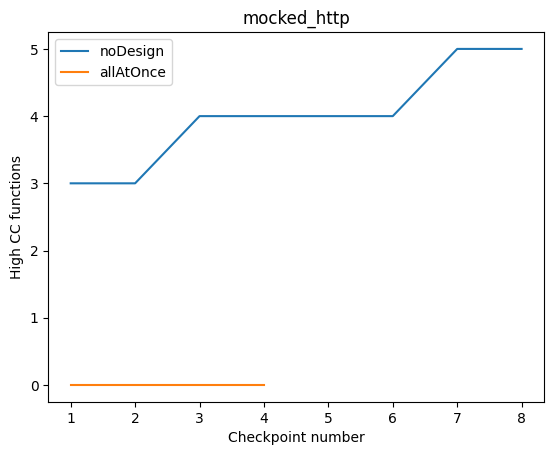

In [14]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["function_cyclomatic_complexity_count"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("High CC functions")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

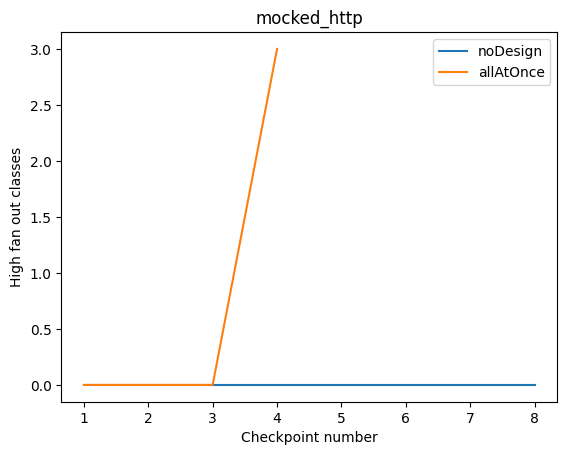

In [15]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["high_fan_out_classes_count"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("High fan out classes")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Logical lines of code
## Maintainability index

In [16]:
import os 
from metrics.radon.overall_metrics import get_radon_metrics

# An array of arrays, each of length N 
# where N is the number of checkpoints of the problem 
data = [] 

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint 
    mode_metrics = []  # metrics of all checkpoints, for a single mode 
    for i, checkpoint_name in enumerate(checkpoint_dirs): 
        impl_dir = dirs[mode_no] / checkpoint_name
        
        mode_metrics.append(
            get_radon_metrics(implementation_path=impl_dir)
        )
    
    data.append(mode_metrics) 

print(data)

[[{'lloc': 626, 'weighted_maintainability_index': 22.31616503470479}, {'lloc': 817, 'weighted_maintainability_index': 15.870322025392921}, {'lloc': 1138, 'weighted_maintainability_index': 14.93809345983469}, {'lloc': 1300, 'weighted_maintainability_index': 12.416654427819257}, {'lloc': 1646, 'weighted_maintainability_index': 15.661847982590084}, {'lloc': 1870, 'weighted_maintainability_index': 15.975853365566406}, {'lloc': 2424, 'weighted_maintainability_index': 15.520009872760715}, {'lloc': 2931, 'weighted_maintainability_index': 16.294594918391503}], [{'lloc': 826, 'weighted_maintainability_index': 48.381884901372594}, {'lloc': 1085, 'weighted_maintainability_index': 50.45818539053899}, {'lloc': 1485, 'weighted_maintainability_index': 50.65591717221941}, {'lloc': 1772, 'weighted_maintainability_index': 50.015964506819095}]]


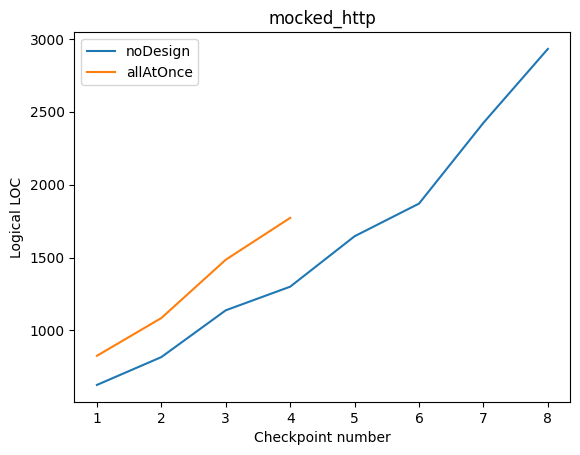

In [17]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["lloc"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Logical LOC")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

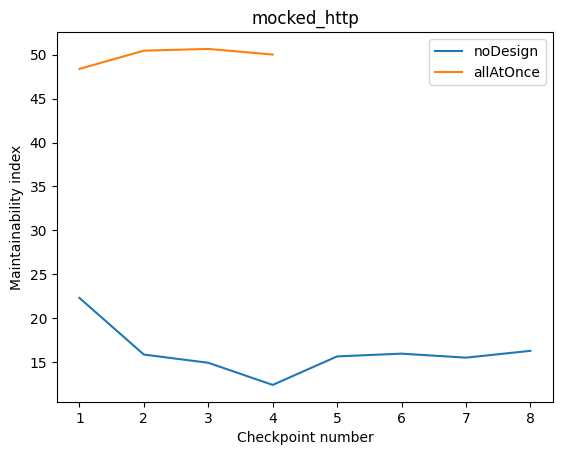

In [18]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["weighted_maintainability_index"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Maintainability index")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Duplicated lines percentage

In [19]:
import os 
from metrics.jscpd.overall_metrics import get_duplicates

# An array of arrays, each of length N 
# where N is the number of checkpoints of the problem 
data = [] 

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint 
    mode_metrics = []  # metrics of all checkpoints, for a single mode 
    for i, checkpoint_name in enumerate(checkpoint_dirs): 
        impl_dir = dirs[mode_no] / checkpoint_name
        
        mode_metrics.append(
            get_duplicates(implementation_path=impl_dir)
        )
    
    data.append(mode_metrics) 

print(data)

[[{'lines': 0.0, 'tokens': 0.0}, {'lines': 0.008249312557286892, 'tokens': 0.009155645981688708}, {'lines': 0.006008010680907877, 'tokens': 0.006635769959974721}, {'lines': 0.0052693208430913355, 'tokens': 0.005813416997323984}, {'lines': 0.004221388367729831, 'tokens': 0.004714863044454423}, {'lines': 0.003708281829419036, 'tokens': 0.004153754862530494}, {'lines': 0.0428979980934223, 'tokens': 0.048953186286995055}, {'lines': 0.04821475110763617, 'tokens': 0.05454468695909148}], [{'lines': 0.0, 'tokens': 0.0}, {'lines': 0.0, 'tokens': 0.0}, {'lines': 0.0, 'tokens': 0.0}, {'lines': 0.0, 'tokens': 0.0}]]


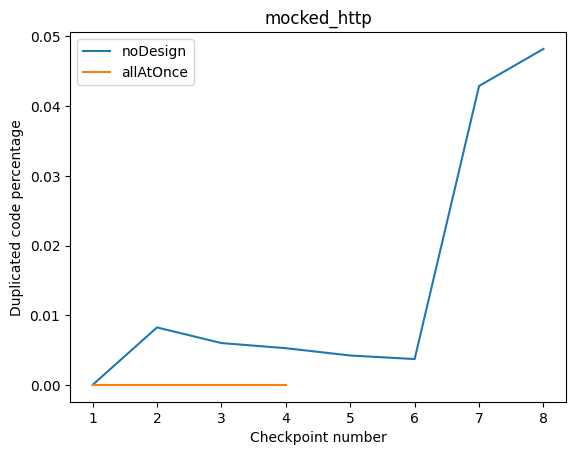

In [20]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["lines"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Duplicated code percentage")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Deps graph

In [21]:
from metrics.deps_graph.overall_metrics import get_deps_graph_metrics
import os 

data = [] 
for mode_no, mode in enumerate(MODES): 

    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint pairs 
    mode_metrics = []  # metrics of all checkpoints, for a single mode 
    for i, checkpoint_name in enumerate(checkpoint_dirs): 
        impl_dir = dirs[mode_no] / checkpoint_name
        
        mode_metrics.append(
            get_deps_graph_metrics(impl_dir) 
        )
    
    data.append(mode_metrics) 
print(data)

[GRAPH 1/4] Generating temp entrypoint file
[GRAPH 2/4] Generating dependency graph
[GRAPH 3/4] Converting the dependency graphs to JSON
Dependency graph has 5 modules.
[GRAPH 4/4] Removing temp file
[GRAPH 1/4] Generating temp entrypoint file
[GRAPH 2/4] Generating dependency graph
[GRAPH 3/4] Converting the dependency graphs to JSON
Dependency graph has 5 modules.
[GRAPH 4/4] Removing temp file
[GRAPH 1/4] Generating temp entrypoint file
[GRAPH 2/4] Generating dependency graph
[GRAPH 3/4] Converting the dependency graphs to JSON
Dependency graph has 6 modules.
[GRAPH 4/4] Removing temp file
[GRAPH 1/4] Generating temp entrypoint file
[GRAPH 2/4] Generating dependency graph
[GRAPH 3/4] Converting the dependency graphs to JSON
Dependency graph has 6 modules.
[GRAPH 4/4] Removing temp file
[GRAPH 1/4] Generating temp entrypoint file
[GRAPH 2/4] Generating dependency graph
[GRAPH 3/4] Converting the dependency graphs to JSON
Dependency graph has 8 modules.
[GRAPH 4/4] Removing temp file


## Has cycles

In [22]:
for i, entry in enumerate(data): 
    print(f"{MODES[i]}: {[x["hasCycles"] for x in entry]}")

noDesign: [False, False, False, False, False, False, False, False]
allAtOnce: [False, False, False, False]


## Propagation cost

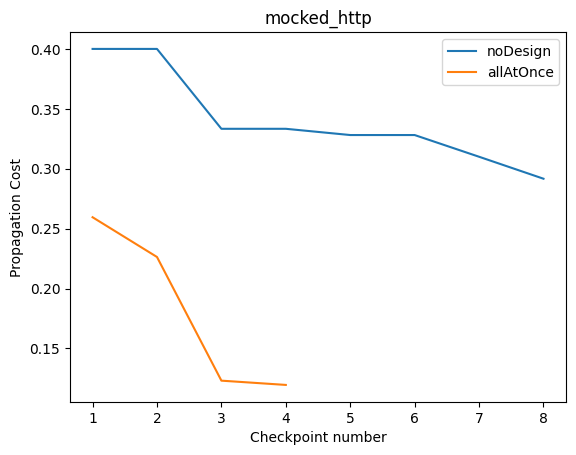

In [23]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z["propagationCost"] for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Propagation Cost")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Maintenance effort

Files change together and the changed proportion

In [24]:
from metrics.maintenance_effort.overall_metrics import get_changed_files
from collections import defaultdict


for mode_no, mode in enumerate(MODES): 
    pairs = defaultdict(int) 

    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint pairs 
    mode_metrics = []  # metrics of all checkpoints, for a single mode 
    for i in range(len(checkpoint_dirs)-1): 
        old_checkpoint = checkpoint_dirs[i] 
        new_checkpoint = checkpoint_dirs[i+1]
        changed_files = get_changed_files(
            dirs[mode_no] / old_checkpoint, 
            dirs[mode_no] / new_checkpoint
        )
        
        # Walk through each pairs 
        for i in range(len(changed_files)): 
            for j in range(i+1, len(changed_files)): 
                pairs[(changed_files[i], changed_files[j])] += 1 
        
    view = [(key, value) for key, value in pairs.items()]
    view.sort(key=lambda x: x[1], reverse=True)
    print('\n'.join([str(x) for x in view]))
    print("="*50)

(('mock_loader.py', 'http_server.py'), 7)
(('mock_loader.py', 'hmock.py'), 6)
(('http_server.py', 'hmock.py'), 6)
(('mock_loader.py', 'template_engine.py'), 4)
(('http_server.py', 'template_engine.py'), 4)
(('template_engine.py', 'hmock.py'), 3)
(('mock_loader.py', 'mock_store.py'), 2)
(('http_server.py', 'mock_store.py'), 2)
(('hmock.py', 'mock_store.py'), 2)
(('mock_loader.py', 'redis_backend.py'), 1)
(('http_server.py', 'redis_backend.py'), 1)
(('template_engine.py', 'redis_backend.py'), 1)
(('redis_backend.py', 'hmock.py'), 1)
(('mock_loader.py', 'admin_server.py'), 1)
(('http_server.py', 'admin_server.py'), 1)
(('admin_server.py', 'hmock.py'), 1)
(('admin_server.py', 'mock_store.py'), 1)
(('hmock_schema.py', 'hmock_template_evaluator.py'), 3)
(('hmock_schema.py', 'hmock_loader.py'), 2)
(('hmock_template_evaluator.py', 'hmock_loader.py'), 2)
(('hmock_matcher.py', 'hmock_template.py'), 2)
(('hmock_matcher.py', 'hmock.py'), 2)
(('hmock_matcher.py', 'hmock_models.py'), 2)
(('hmock_mat

## 

## Proportion of code that is changed

In [25]:
from metrics.maintenance_effort.overall_metrics import get_changed_proportion
import os 

data = [] 
for mode_no, mode in enumerate(MODES): 

    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # walk through each checkpoint pairs 
    mode_metrics = []  # metrics of all checkpoints, for a single mode 
    for i in range(len(checkpoint_dirs)-1): 
        old_checkpoint = checkpoint_dirs[i] 
        new_checkpoint = checkpoint_dirs[i+1]
        p = get_changed_proportion(
            dirs[mode_no] / old_checkpoint, 
            dirs[mode_no] / new_checkpoint
        )
        mode_metrics.append(p) 
    data.append(mode_metrics)
print(data)

[[0.6, 0.8, 0.6666666666666666, 0.8333333333333334, 0.625, 0.3333333333333333, 0.36363636363636365], [0.23529411764705882, 0.37037037037037035, 0.275]]


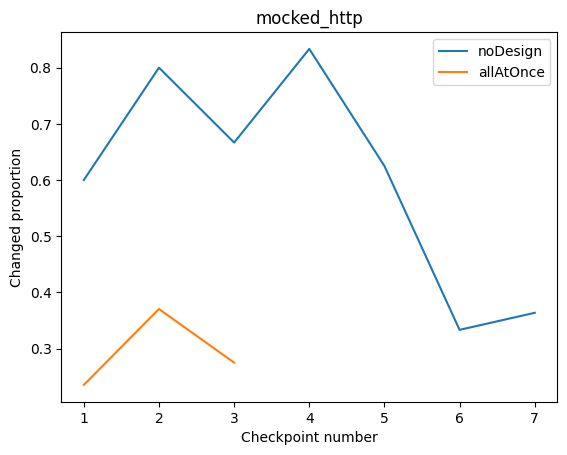

In [26]:
from matplotlib import pyplot as plt 

for i, entry in enumerate(data): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = [z for z in entry]
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Changed proportion")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Weighted propagation cost: Unused
Files that change more frequently have a greater impact on the propagation cost.

In [27]:
# from matplotlib import pyplot as plt 

# for i, entry in enumerate(data): 
#     x = range(1, len(entry)+1)  # make the x axis 1 indexed 
#     y = [z["impactSize"] for z in entry]
#     plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
# plt.xlabel("Checkpoint number")
# plt.ylabel("Impact size")
# plt.title(PROBLEM) 

# plt.legend() 
# plt.show() 

In [28]:
# import os 
# from deterministic.overall_metrics.maintenance_effort import get_changed_files_from_history

# # An array of arrays, each of length N 
# # where N is the number of checkpoints of the problem 
# data = [] 

# for mode_no, mode in enumerate(MODES): 
#     # Obtain the checkpoint directories names of the problem
#     # checkpoint_1, checkpoint_2, ... checkpoint_N
#     checkpoint_dirs = []
#     for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
#         # only extract the top level iteration 
#         checkpoint_dirs = dir 
#         break 
#     checkpoint_dirs.sort() 

#     # walk through each checkpoint 
#     checkpoint_dirs_abs = [dirs[mode_no] / checkpoint_name for checkpoint_name in checkpoint_dirs]
#     d = get_changed_files_from_history(checkpoint_dirs_abs)
#     print(d)

# print(data)

In [29]:
# from deterministic.overall_metrics.deps_graph import get_weighted_deps_graph_metrics
# import os 
# from deterministic.overall_metrics.maintenance_effort import get_changed_files_from_history

# data = [] 
# for mode_no, mode in enumerate(MODES): 

#     # Obtain the checkpoint directories names of the problem
#     # checkpoint_1, checkpoint_2, ... checkpoint_N
#     checkpoint_dirs = []
#     for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
#         # only extract the top level iteration 
#         checkpoint_dirs = dir 
#         break 
#     checkpoint_dirs.sort() 

#     checkpoint_dirs_abs = [dirs[mode_no] / checkpoint_name for checkpoint_name in checkpoint_dirs]
#     d = get_changed_files_from_history(checkpoint_dirs_abs)

#     # walk through each checkpoint pairs 
#     mode_metrics = []  # metrics of all checkpoints, for a single mode 
#     for i, checkpoint_name in enumerate(checkpoint_dirs): 
#         impl_dir = dirs[mode_no] / checkpoint_name
        
#         mode_metrics.append(
#             get_weighted_deps_graph_metrics(d, impl_dir)
#         )
    
#     data.append(mode_metrics) 
# print(data)

In [30]:
# from matplotlib import pyplot as plt 

# for i, entry in enumerate(data): 
#     x = range(1, len(entry)+1)  # make the x axis 1 indexed 
#     y = [z["density"] for z in entry]
#     plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
# plt.xlabel("Checkpoint number")
# plt.ylabel("Density")
# plt.title(PROBLEM) 

# plt.legend() 
# plt.show() 